### Pràctica 2: Aprenentatge no supervisat

### Imports

In [53]:
import numpy as np
import pandas as pd
from IPython.display import display
import math
from sklearn.preprocessing import StandardScaler
# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Autoencoders
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

#SOM
from minisom import MiniSom

# Metrics / comparison with real classes
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

# Plots
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from collections import Counter
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

2.12.0+cu130
CUDA available: False


### 1. Lectura de les dades.

In [28]:
# dades sintètiques
synthetic_original = pd.read_csv("A2-synthetic.txt", sep=",")

#dades reals
real_original = pd.read_csv("A2-real.txt", sep=";")

In [29]:
#print(synthetic_original.head())
print(synthetic_original.shape)

#print(real_original.head())
print(real_original.shape)

(360, 5)
(333, 7)


### 2. Pre-processament de les dades

In [30]:
synthetic = synthetic_original.copy()
real = real_original.copy()

Separem les variables que s’utilitzaran com a entrada de les variables auxiliars. Les etiquetes de classe no s’han d’utilitzar durant l’entrenament dels models, sinó només per visualitzar i comparar els resultats obtinguts. En el cas del dataset real, la variable Location tampoc es fa servir per entrenar, però es conserva per a la interpretació posterior dels gràfics.

In [31]:
# Synthetic
X_syn = synthetic.drop(columns=["class"])
y_syn = synthetic["class"]

# Real
X_real = real.drop(columns=["Class", "Location"])
y_real = real["Class"]
location_real = real["Location"]

In [32]:
display(y_syn.value_counts())
display(y_real.value_counts())
display(location_real.value_counts())

class
2    100
6    100
1     63
4     40
5     36
3     21
Name: count, dtype: int64

Class
C1    146
C2    119
C3     68
Name: count, dtype: int64

Location
L2    163
L3    123
L1     47
Name: count, dtype: int64

Hem comprovat la distribució de les classes en els dos datasets i de la variable Location en el dataset real. Observem que les dades no estan perfectament balancejades, ja que algunes classes tenen molts més patrons que d’altres. Això és important per interpretar els gràfics posteriorment, ja que els grups més grans poden dominar visualment els resultats, mentre que els grups més petits poden ser més difícils d’identificar.

In [33]:
scaler_syn = StandardScaler()
X_syn_scaled = scaler_syn.fit_transform(X_syn)

scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(X_real)

Per finalitzar el preprocessament, estandarditzem les variables d’entrada. Aquest pas és important perquè molts dels mètodes utilitzats depenen de distàncies, variàncies o processos d’optimització, i per tant variables amb escales més grans podrien tenir un pes excessiu. Guardarem les dades ja escalades tant en format DataFrame, per conservar els noms de les variables i facilitar la visualització, com en format array, que resulta més pràctic per aplicar alguns algoritmes.

In [34]:
# Keep scaled data as DataFrame
X_syn_scaled_df = pd.DataFrame(
    X_syn_scaled,
    columns=X_syn.columns,
    index=X_syn.index
)

X_real_scaled_df = pd.DataFrame(
    X_real_scaled,
    columns=X_real.columns,
    index=X_real.index
)

# Also keep NumPy arrays for algorithms: PCA, t-SNE, k-means, AHC, Autoencoder, SOM.
X_syn_scaled_np = X_syn_scaled_df.values
X_real_scaled_np = X_real_scaled_df.values

# Display first rows
display(X_syn_scaled_df.head())
display(X_real_scaled_df.head())

,x1,x2,x3,x4
0,-0.165933,-2.165686,-1.125643,-0.218701
1,-0.075211,1.121416,-0.169405,-0.207301
2,0.403832,-0.219275,0.559468,-0.413849
3,-0.194014,-0.547981,-1.391632,-0.806953
4,-0.248522,-0.225249,0.663554,-0.999257


,BL,BD,FL,BM,S
0,-1.738463,0.475587,-0.998018,-1.625681,1.009050
1,-0.950982,1.441880,-0.783651,-0.319720,-0.991031
2,0.202768,-1.355285,0.431094,1.048429,1.009050
3,-1.720150,2.001313,-0.212006,0.239977,-0.991031
4,-0.621339,0.933305,-0.140551,-0.257532,-0.991031


### 3. Aplicar sis tècniques d’aprenentatge no supervisat:


### PCA: 

La idea del PCA és reduir les dades originals a només dues components principals, conservant les direccions on les dades tenen més variància. Això permet representar dades de més dimensions en un gràfic 2D, perdent la mínima informació possible. En aquest cas, s’utilitza per visualitzar si les classes formen grups diferenciats en l’espai reduït.

In [35]:
def apply_pca(X_scaled, y, dataset_name):
    """
    Applies PCA to a scaled dataset.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled input features.
    y : Series
        Real classes. Only used for plotting, not for fitting PCA.
    dataset_name : str
        Name of the dataset for plot titles.

    Returns
    -------
    pca_df : DataFrame
        DataFrame with PC1, PC2 and class.
    pca : PCA object
        Fitted PCA model.
    """

    #mirem quantes variables té el dataset per aplicar un PCA amb tantes components com variables
    n_components = X_scaled.shape[1]
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled) #matriu amb coordenades de cada pt en l'espai PCA
    print(X_pca.shape)
    
    # Seleccionem totes les files i només les dues primeres columnes de la projecció PCA
    # corresponents a les dues primeres components principals: PC1 i PC2.
    pca_df = pd.DataFrame(
        X_pca[:, :2], 
        columns=["PC1", "PC2"],
        index=X_scaled.index if hasattr(X_scaled, "index") else None
        #conservem index si es un df, si es un array none
    )
    
    #afegim la classe real
    pca_df["class"] = y.values

    #guardem varinaça
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    #Projecció PCA
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="class",
        palette="tab10",
        s=60
    )

    plt.title(f"Projecció PCA  - {dataset_name}")
    plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variança)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variança)")
    plt.legend(title="Classe")
    plt.grid(True)
    plt.show()

    # 2. Scree plot: variança acumulada en funció del nre de components
    plt.figure(figsize=(7, 5))
    plt.plot(
        range(1, n_components + 1),
        cumulative_variance,
        marker="o"
    )

    plt.title(f"Scree plot - {dataset_name}")
    plt.xlabel("Nombre de components principals")
    plt.ylabel("Variança acumulada")
    plt.xticks(range(1, n_components + 1))
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()

    return pca_df, pca

(360, 4)


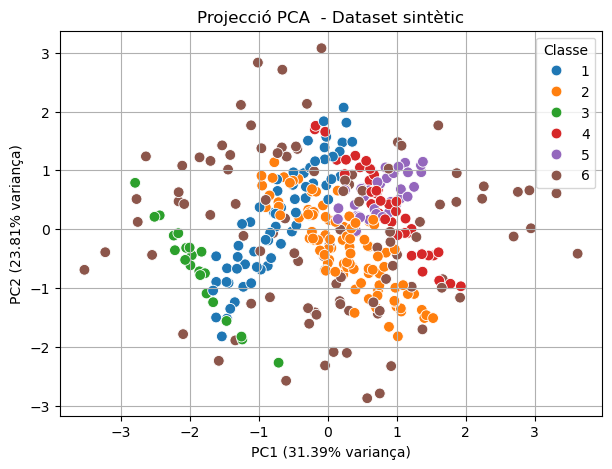

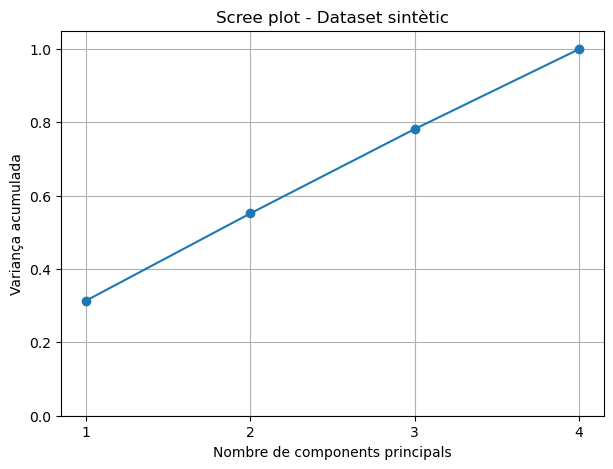

(333, 5)


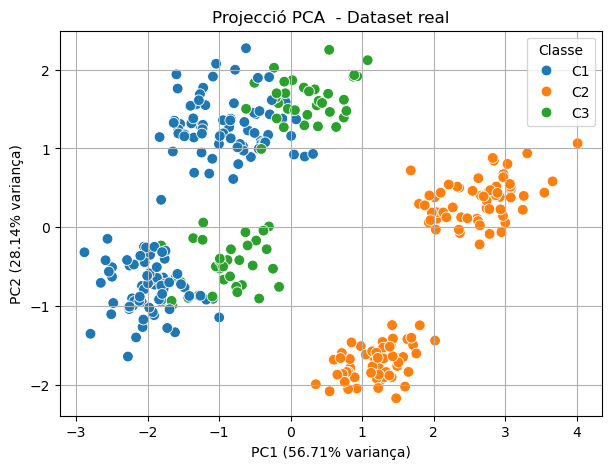

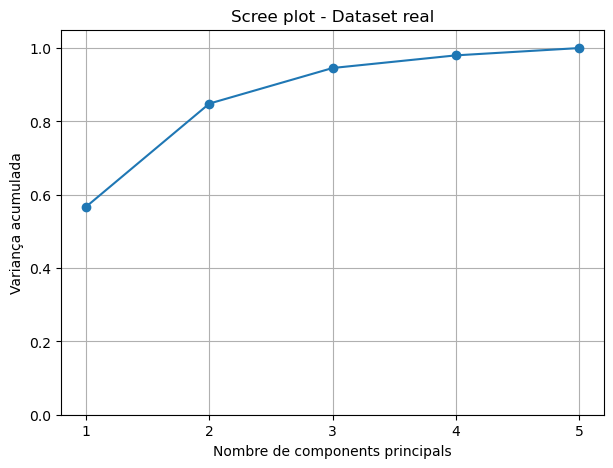

,PC1,PC2,class
0,-1.615413,-0.461632,1
1,0.499510,0.700627,5
2,0.603876,-0.296531,2
3,-0.726266,0.649637,1
4,0.633048,0.427483,4


,PC1,PC2,class
0,-2.653307,-0.704220,C1
1,-1.313026,1.563658,C1
2,1.139419,-1.578386,C2
3,-1.221611,1.771707,C1
4,-0.594826,1.229541,C1


In [36]:
# PCA per dades sintetiques
pca_syn_df, pca_syn = apply_pca(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic"
)

# PCA per dades reals
pca_real_df, pca_real = apply_pca(
    X_real_scaled_df,
    y_real,
    "Dataset real"
)

# Show results
display(pca_syn_df.head())
display(pca_real_df.head())

#### Conclusions PCA

En el dataset sintètic, la projecció PCA mostra un solapament important entre les classes. Això és coherent amb el scree plot, ja que les dues primeres components principals només acumulen aproximadament un 60% de la variància total. Per tant, en reduir les dades a dues dimensions es perd una part rellevant de la informació, i és possible que part de la separació entre classes quedi en components posteriors.

En canvi, en el dataset real s’observa una separació més clara entre les classes, especialment per a la classe C2. En aquest cas, les dues primeres components principals acumulen aproximadament un 85% de la variància total, de manera que la representació en dues dimensions conserva gran part de la informació original. Això fa que el PCA sigui més adequat per visualitzar l’estructura del dataset real que la del dataset sintètic.

### t-SNE


In [37]:
def apply_tsne(X_scaled, y, dataset_name, perplexities=[5, 10, 30, 50]):
    """
    Applies t-SNE with different perplexity values and plots the 2D projections.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled input features.
    y : Series
        Real classes. Only used for plotting, not for fitting t-SNE.
    dataset_name : str
        Name of the dataset.
    perplexities : list
        List of perplexity values to test.

    Returns
    -------
    tsne_results : dict
        Dictionary containing one DataFrame per perplexity.
    """

    tsne_results = {}

    n_samples = X_scaled.shape[0]

    for perplexity in perplexities:

        if perplexity >= n_samples:
            print(f"Skipping perplexity={perplexity}, because it must be smaller than n_samples={n_samples}")
            continue

        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            random_state=RANDOM_STATE
        )

        X_tsne = tsne.fit_transform(X_scaled)

        tsne_df = pd.DataFrame(
            X_tsne,
            columns=["tSNE1", "tSNE2"],
            index=X_scaled.index if hasattr(X_scaled, "index") else None
        )

        tsne_df["class"] = y.values

        tsne_results[perplexity] = tsne_df

        plt.figure(figsize=(7, 5))
        sns.scatterplot(
            data=tsne_df,
            x="tSNE1",
            y="tSNE2",
            hue="class",
            palette="tab10",
            s=60
        )

        plt.title(f"t-SNE projection - {dataset_name} - perplexity={perplexity}")
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.legend(title="Class")
        plt.grid(True)
        plt.show()

    return tsne_results

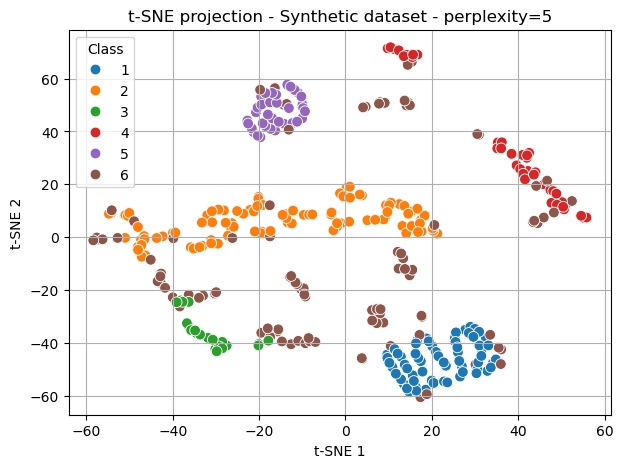

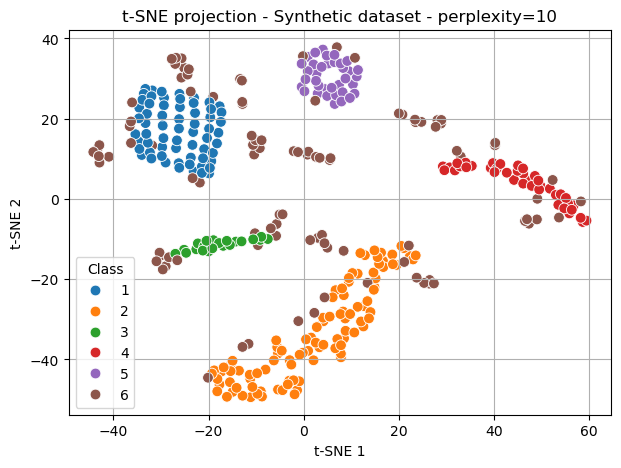

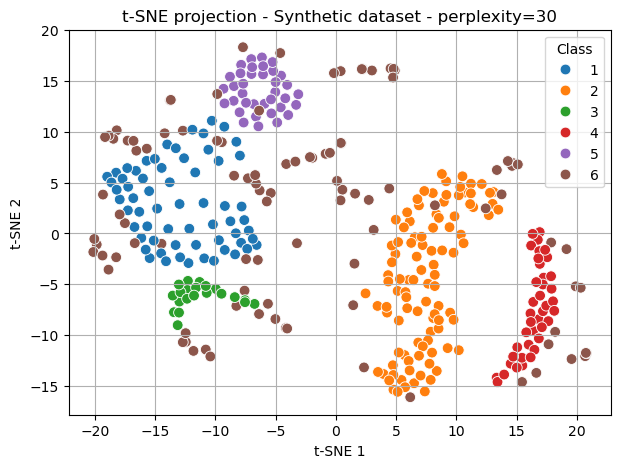

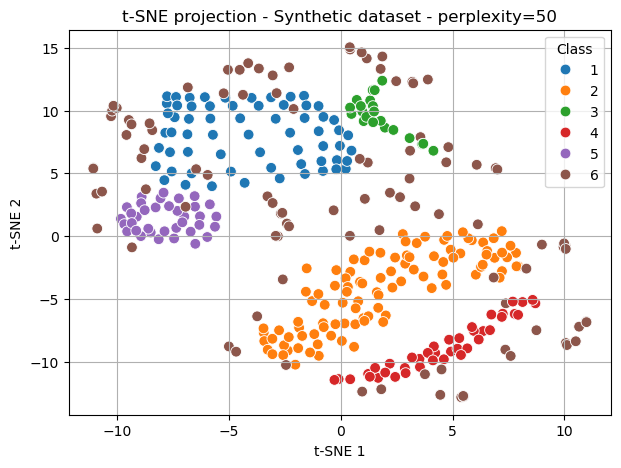

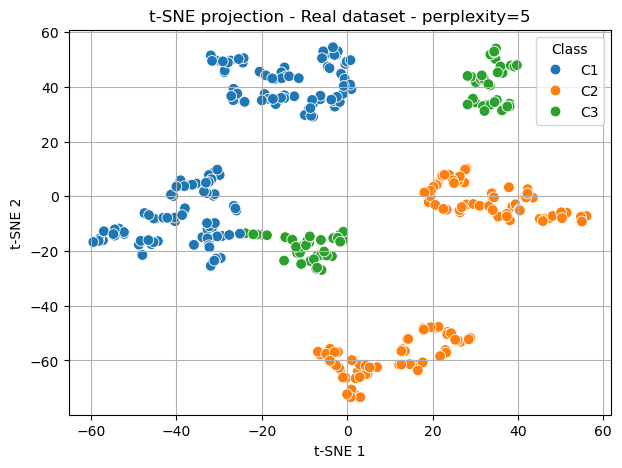

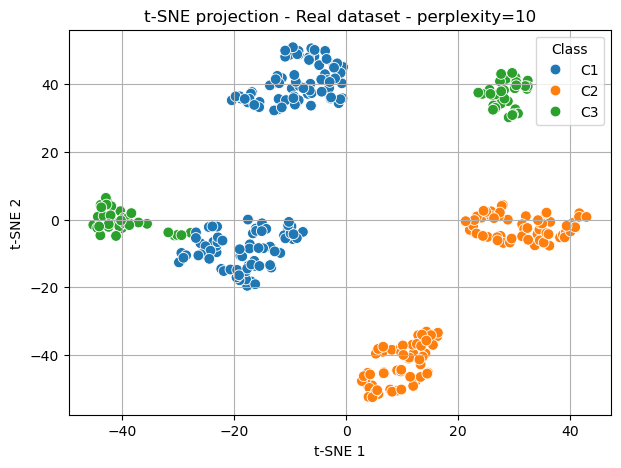

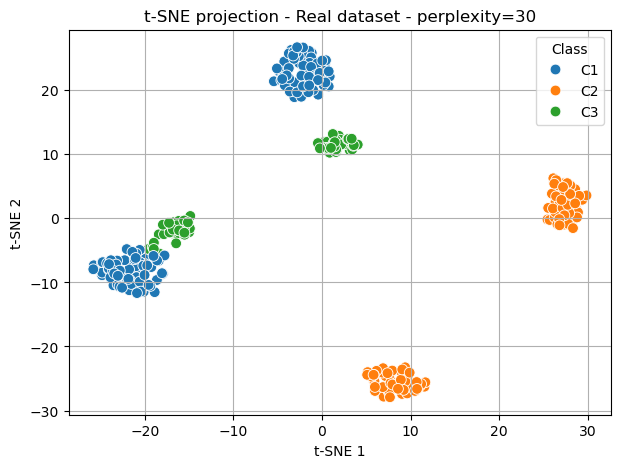

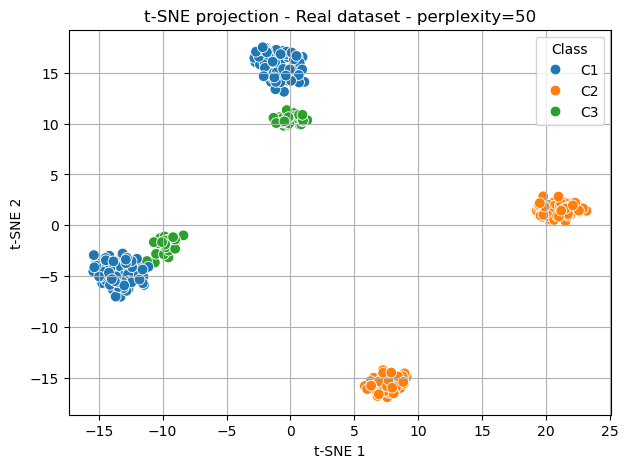

,tSNE1,tSNE2,class
0,-23.529404,-10.444178,C1
1,-4.385883,22.853743,C1
2,9.032087,-27.406357,C2
3,-5.420836,21.394278,C1
4,-1.218725,21.740320,C1


In [38]:
tsne_syn_results = apply_tsne(
    X_syn_scaled_df,
    y_syn,
    "Synthetic dataset",
    perplexities=[5, 10, 30, 50]
)

tsne_real_results = apply_tsne(
    X_real_scaled_df,
    y_real,
    "Real dataset",
    perplexities=[5, 10, 30, 50]
)

tsne_syn_results[30].head()
tsne_real_results[30].head()

### K-means

In [39]:
def apply_kmeans(X_scaled, pca_df, y_true, dataset_name, k_values):
    """
    Applies k-means for different k values and plots the resulting clusters
    using the PCA coordinates.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled input features. Used to fit k-means.
    pca_df : DataFrame
        DataFrame containing PC1 and PC2 coordinates.
    y_true : Series
        Real class labels. Only used for comparison, not for training.
    dataset_name : str
        Name of the dataset.
    k_values : list or range
        Values of k to test.

    Returns
    -------
    results_df : DataFrame
        Table with ARI and NMI scores for each k.
    kmeans_results : dict
        Dictionary containing the cluster labels for each k.
    """

    results = []
    kmeans_results = {}

    for k in k_values:

        kmeans = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10
        )

        cluster_labels = kmeans.fit_predict(X_scaled)

        kmeans_results[k] = cluster_labels

        ari = adjusted_rand_score(y_true, cluster_labels)
        nmi = normalized_mutual_info_score(y_true, cluster_labels)

        results.append({
            "k": k,
            "ARI": ari,
            "NMI": nmi,
            "Inertia": kmeans.inertia_
        })

        plot_df = pca_df[["PC1", "PC2"]].copy()
        plot_df["cluster"] = cluster_labels
        plot_df["real_class"] = y_true.values

        plt.figure(figsize=(7, 5))
        sns.scatterplot(
            data=plot_df,
            x="PC1",
            y="PC2",
            hue="cluster",
            palette="tab10",
            s=60
        )

        plt.title(f"k-means clustering - {dataset_name} - k={k}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend(title="Cluster")
        plt.grid(True)
        plt.show()

    results_df = pd.DataFrame(results)

    return results_df, kmeans_results

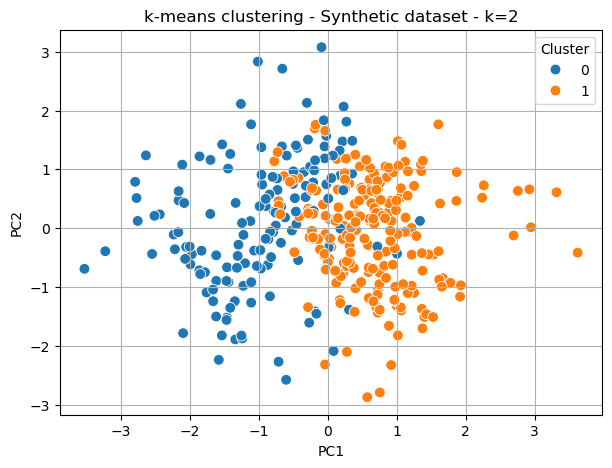

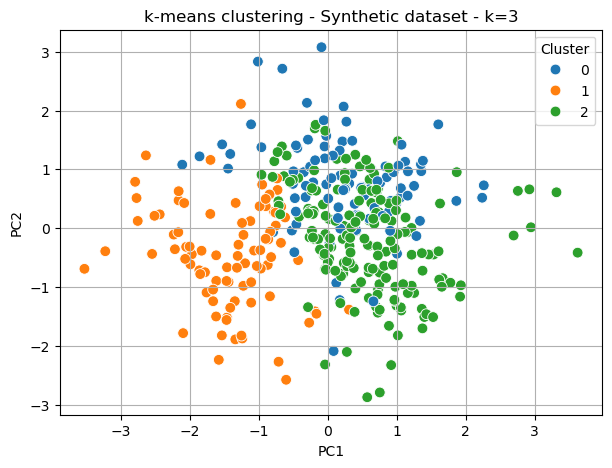

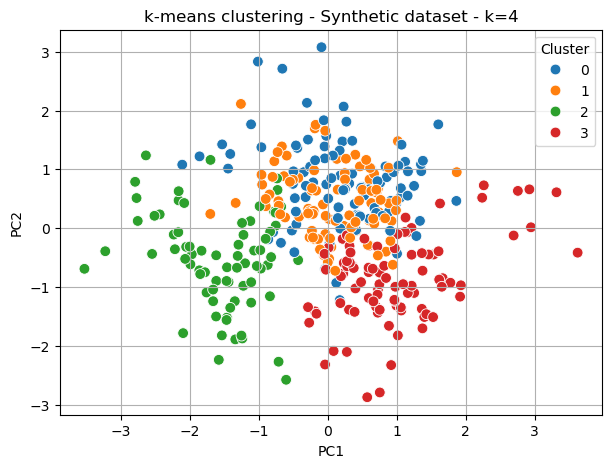

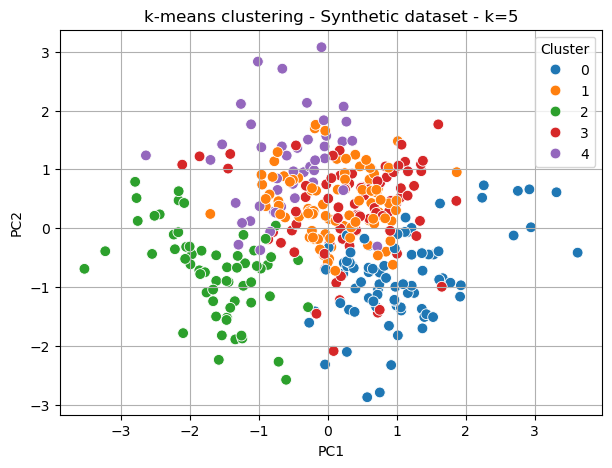

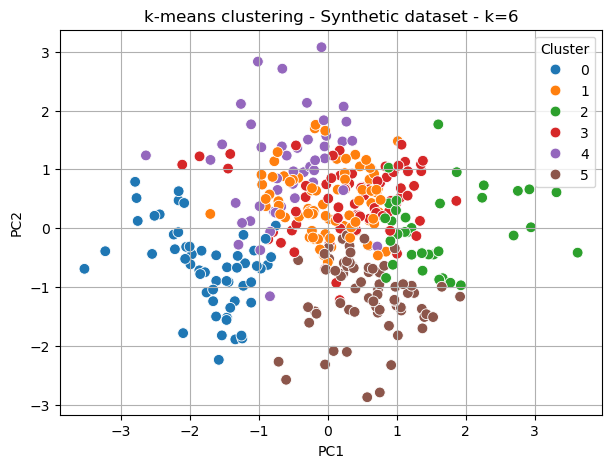

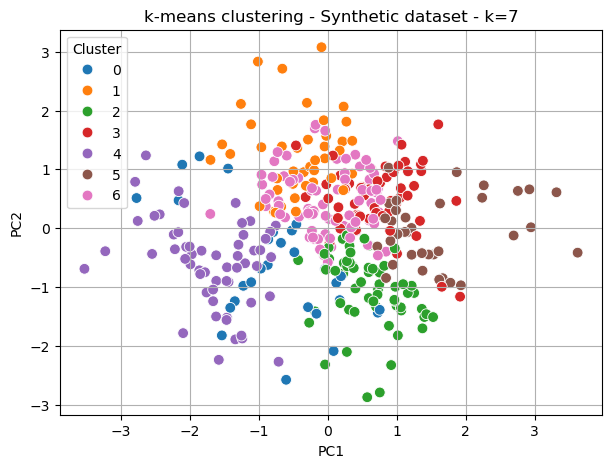

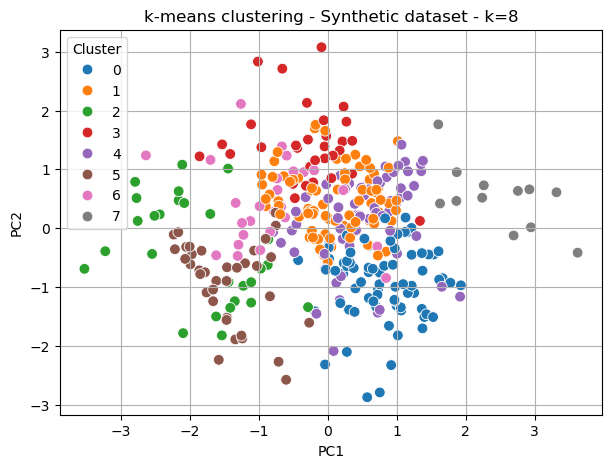

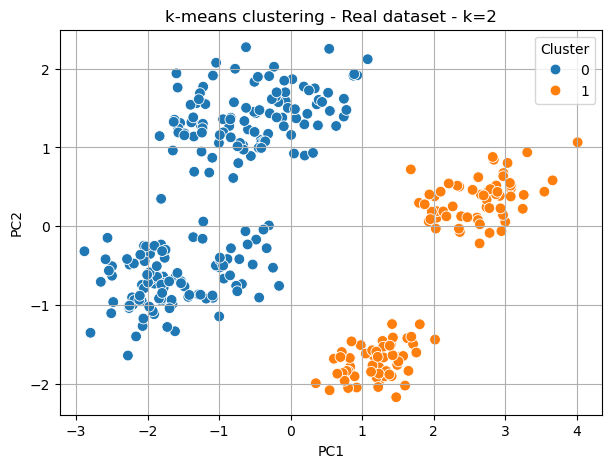

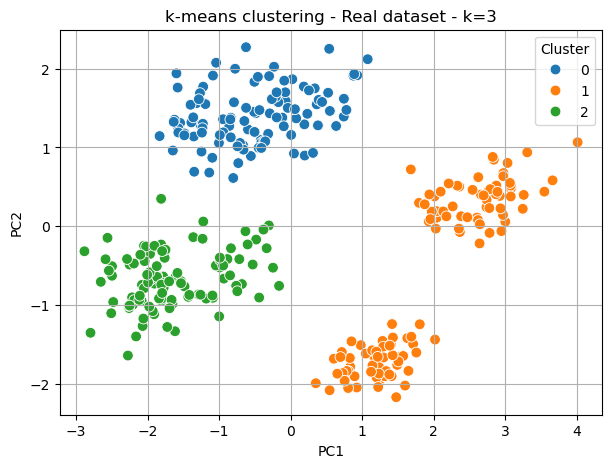

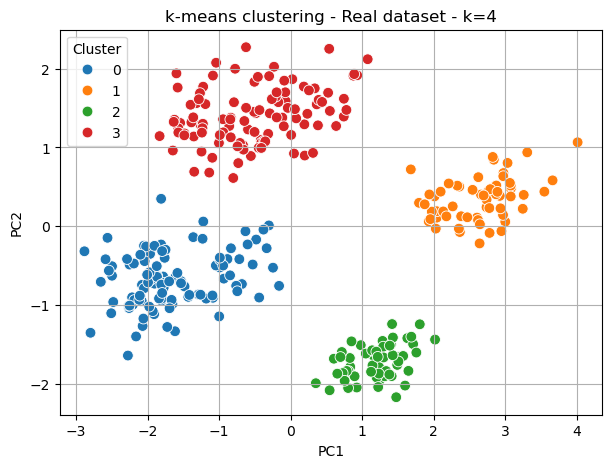

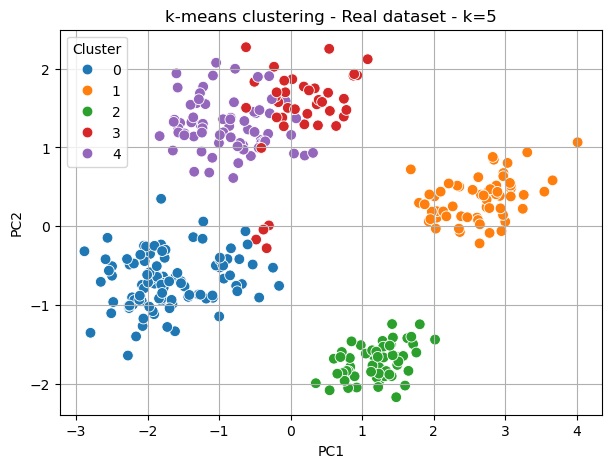

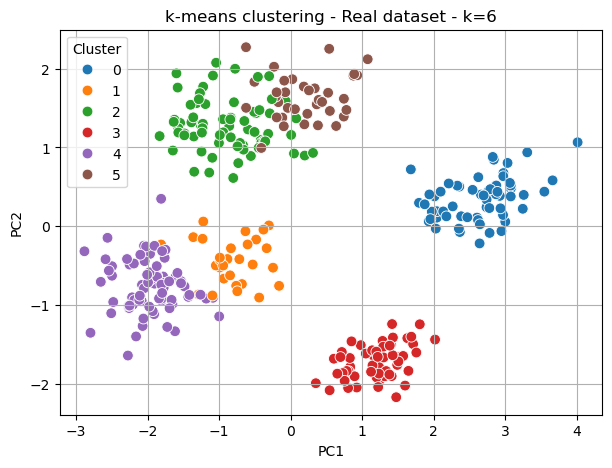

In [40]:
k_values_syn = range(2, 9)

kmeans_syn_results_df, kmeans_syn_results = apply_kmeans(
    X_syn_scaled_df,
    pca_syn_df,
    y_syn,
    "Synthetic dataset",
    k_values_syn
)


k_values_real = range(2, 7)

kmeans_real_results_df, kmeans_real_results = apply_kmeans(
    X_real_scaled_df,
    pca_real_df,
    y_real,
    "Real dataset",
    k_values_real
)

In [41]:
def plot_kmeans_scores(results_df, dataset_name):
    plt.figure(figsize=(7, 5))

    plt.plot(results_df["k"], results_df["ARI"], marker="o", label="ARI")
    plt.plot(results_df["k"], results_df["NMI"], marker="o", label="NMI")

    plt.title(f"k-means comparison with real classes - {dataset_name}")
    plt.xlabel("Number of clusters k")
    plt.ylabel("Score")
    plt.xticks(results_df["k"])
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()

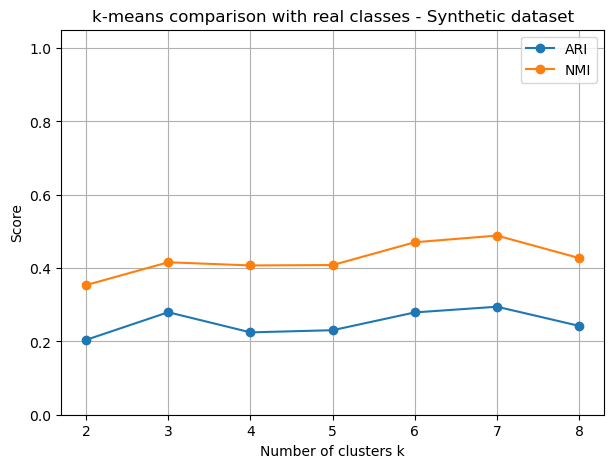

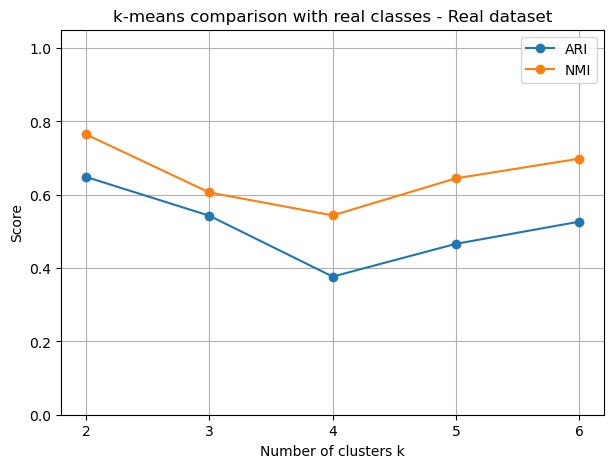

In [42]:
plot_kmeans_scores(kmeans_syn_results_df, "Synthetic dataset")
plot_kmeans_scores(kmeans_real_results_df, "Real dataset")

### 4) AHC

In [43]:
def apply_ahc_dendrograms(X_scaled, y, dataset_name):
    """
    Applies Agglomerative Hierarchical Clustering using Euclidean distances
    and plots dendrograms for UPGMA (average linkage) and complete linkage.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled input features. Used to compute Euclidean distances.
    y : Series
        Real classes. Only used to color the leaves of the dendrogram.
    dataset_name : str
        Name of the dataset.
    """

    # Ensure classes are aligned with the order of X_scaled
    y = pd.Series(y).reset_index(drop=True)

    # Euclidean distance matrix in condensed form.
    # pdist does not return a square matrix, but a compressed version used by scipy.
    distance_matrix = pdist(X_scaled, metric="euclidean")

    # Assign one color to each real class, only for visualization
    classes = sorted(y.unique())
    palette = sns.color_palette("tab10", n_colors=len(classes))
    class_to_color = {cls: palette[i] for i, cls in enumerate(classes)}

    # Methods required in the statement
    methods = {
        "UPGMA / average linkage": "average",
        "Complete linkage": "complete"
    }

    linkage_results = {}

    for title, method in methods.items():

        # Compute hierarchical clustering from the Euclidean distance matrix
        Z = linkage(
            distance_matrix,
            method=method,
            optimal_ordering=True
        )

        linkage_results[method] = Z

        plt.figure(figsize=(18, 7))
        ax = plt.gca()

        dendro = dendrogram(
            Z,
            labels=[str(cls) for cls in y],
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=0,
            above_threshold_color="black",
            ax=ax
        )

        # Color each leaf label according to its real class
        for tick_label, leaf_index in zip(ax.get_xmajorticklabels(), dendro["leaves"]):
            real_class = y.iloc[leaf_index]
            tick_label.set_color(class_to_color[real_class])

        # Legend for the class colors
        legend_elements = [
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=f"Class {cls}",
                markerfacecolor=class_to_color[cls],
                markersize=8
            )
            for cls in classes
        ]

        ax.legend(
            handles=legend_elements,
            title="Real class",
            loc="upper right"
        )

        plt.title(f"AHC dendrogram - {title} - {dataset_name}")
        plt.xlabel("Patterns / real class")
        plt.ylabel("Euclidean distance")
        plt.tight_layout()
        plt.show()

    return linkage_results

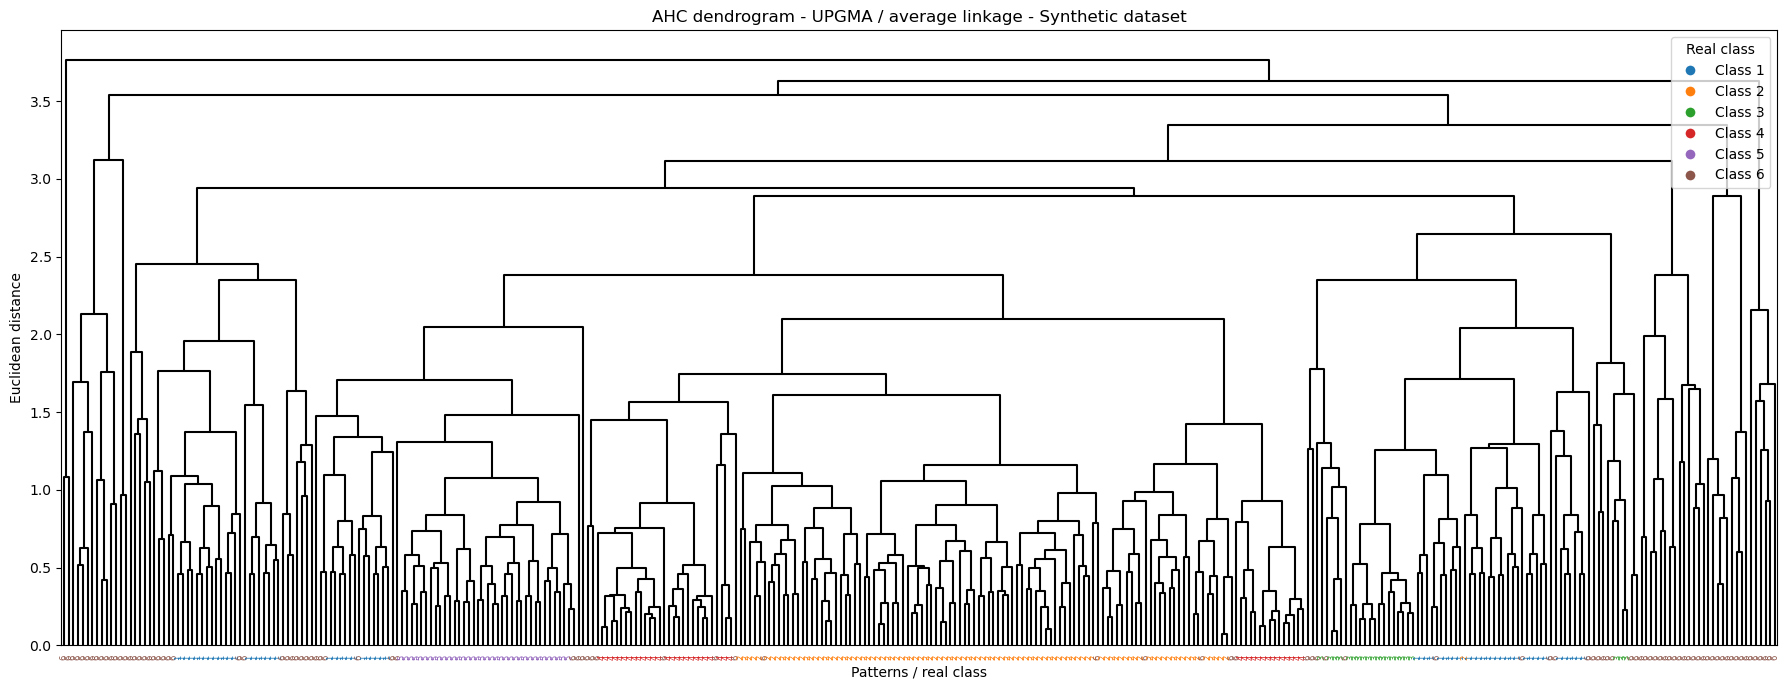

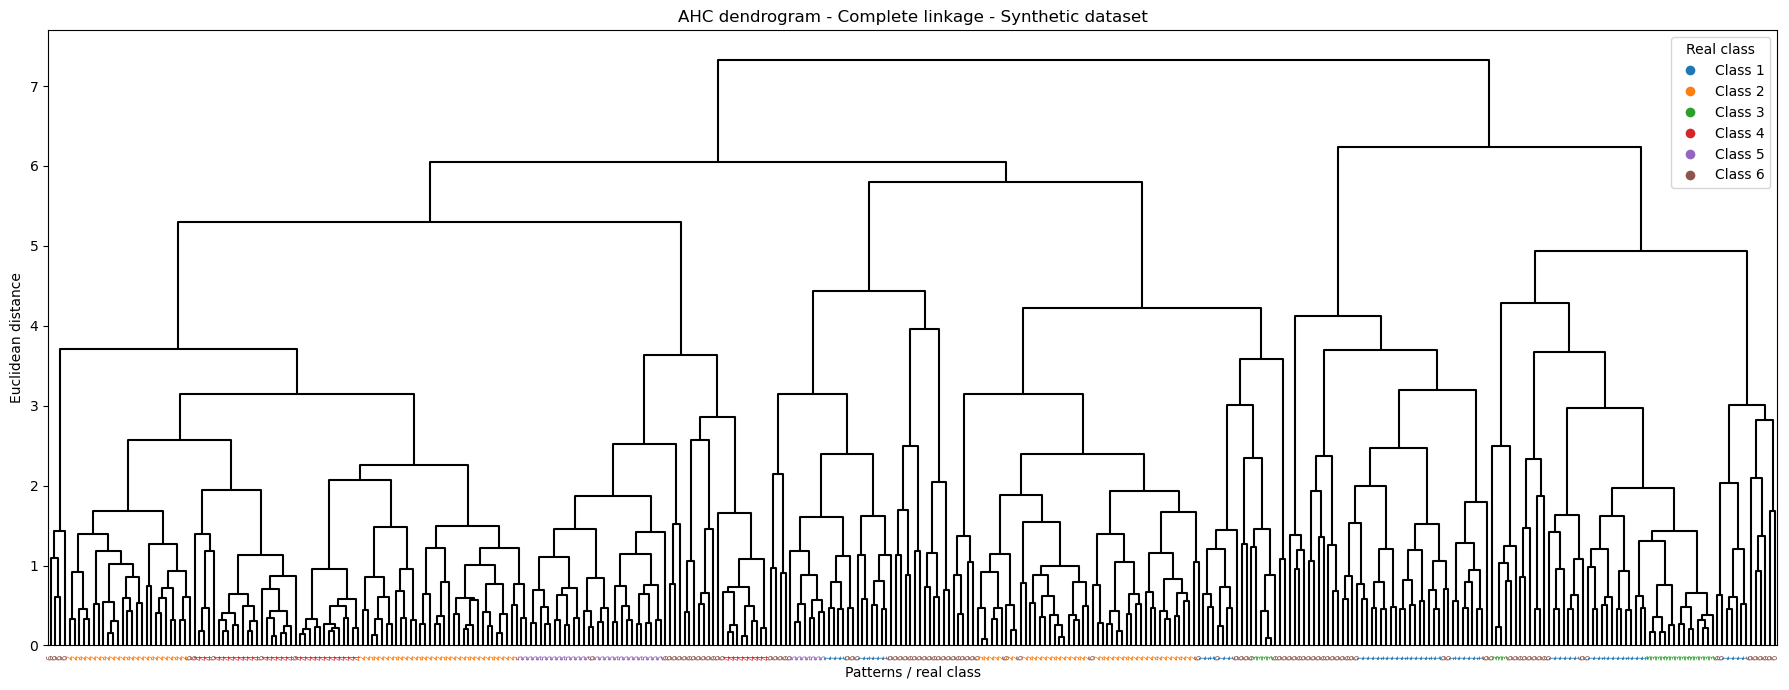

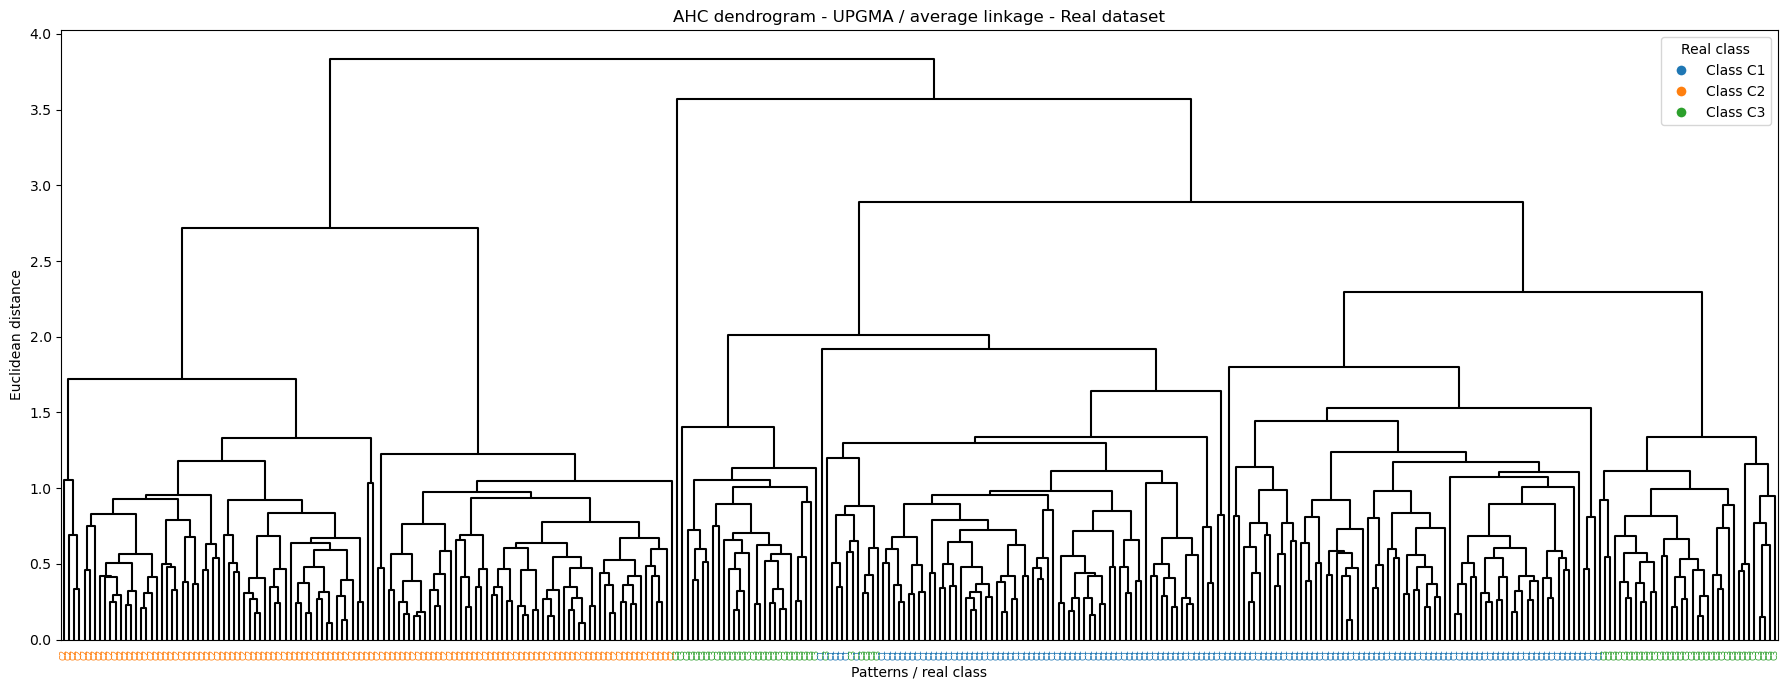

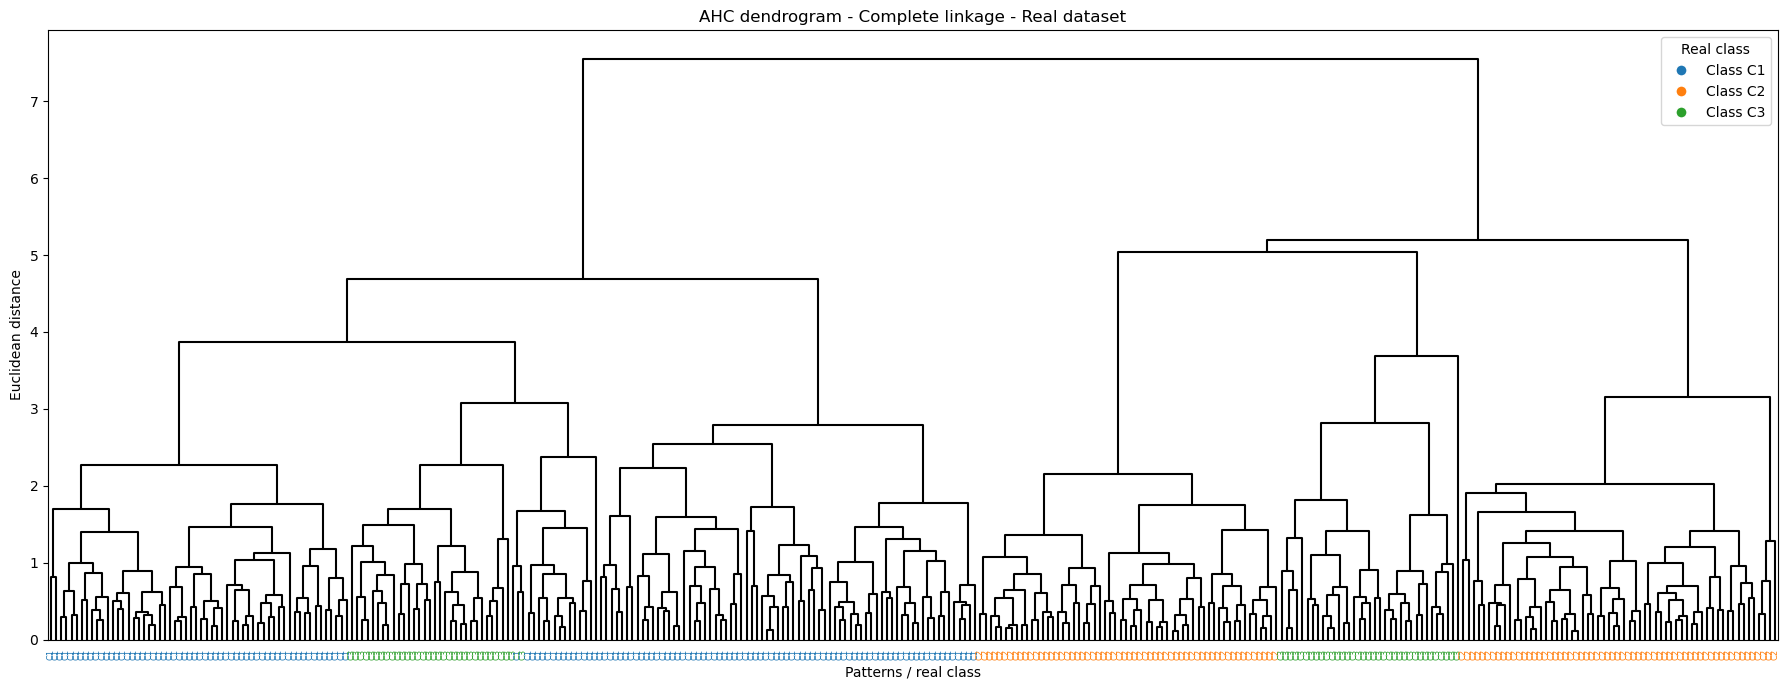

In [44]:
ahc_syn_results = apply_ahc_dendrograms(
    X_syn_scaled_df,
    y_syn,
    "Synthetic dataset"
)

ahc_real_results = apply_ahc_dendrograms(
    X_real_scaled_df,
    y_real,
    "Real dataset"
)

### Autoencoder

In [45]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [46]:
class Autoencoder2D(nn.Module):
    """
    Autoencoder with a 2-dimensional bottleneck.
    The encoder compresses the input data into 2 latent variables,
    and the decoder tries to reconstruct the original input.
    """

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

    def encode(self, x):
        return self.encoder(x)

In [47]:
def train_autoencoder_projection(
    X_scaled,
    y,
    dataset_name,
    hidden_dim=8,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3,
    random_state=42
):
    """
    Trains a PyTorch autoencoder and plots the 2D latent representation.

    Parameters
    ----------
    X_scaled : DataFrame or ndarray
        Scaled original features used as input to the autoencoder.
    y : Series or array
        Real classes. They are only used for visualization.
    dataset_name : str
        Name of the dataset.
    hidden_dim : int
        Number of neurons in the hidden layer.
    epochs : int
        Number of training epochs.
    batch_size : int
        Batch size used during training.
    learning_rate : float
        Learning rate of the Adam optimizer.
    random_state : int
        Seed for reproducibility.
    """

    torch.manual_seed(random_state)
    np.random.seed(random_state)

    X_np = np.asarray(X_scaled, dtype=np.float32)
    y = pd.Series(y).reset_index(drop=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    input_dim = X_np.shape[1]

    model = Autoencoder2D(
        input_dim=input_dim,
        hidden_dim=hidden_dim
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            x_batch = batch[0].to(device)

            reconstructed = model(x_batch)
            loss = criterion(reconstructed, x_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.size(0)

        epoch_loss /= len(dataset)
        losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        X_encoded = model.encode(X_tensor.to(device)).cpu().numpy()

    encoded_df = pd.DataFrame({
        "AE1": X_encoded[:, 0],
        "AE2": X_encoded[:, 1],
        "Class": y
    })

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=encoded_df,
        x="AE1",
        y="AE2",
        hue="Class",
        palette="tab10",
        s=45
    )
    plt.title(f"Autoencoder 2D projection - {dataset_name}")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.title(f"Autoencoder training loss - {dataset_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction loss (MSE)")
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}")
    print(f"Architecture: {input_dim} -> {hidden_dim} -> 2 -> {hidden_dim} -> {input_dim}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {learning_rate}")
    print(f"Final reconstruction loss: {losses[-1]:.6f}")

    return model, encoded_df, losses

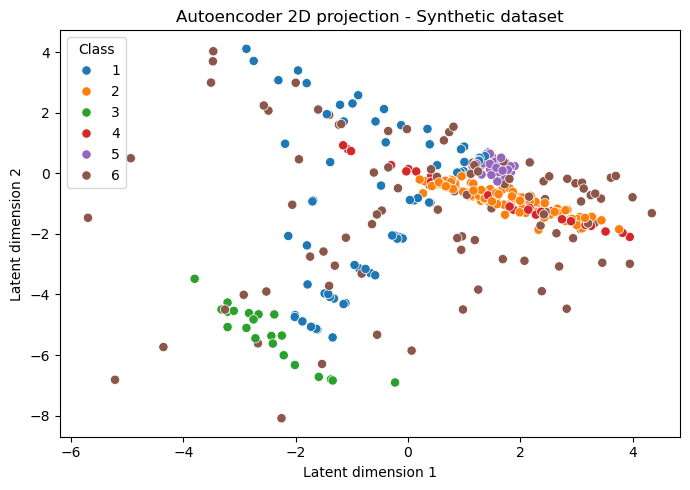

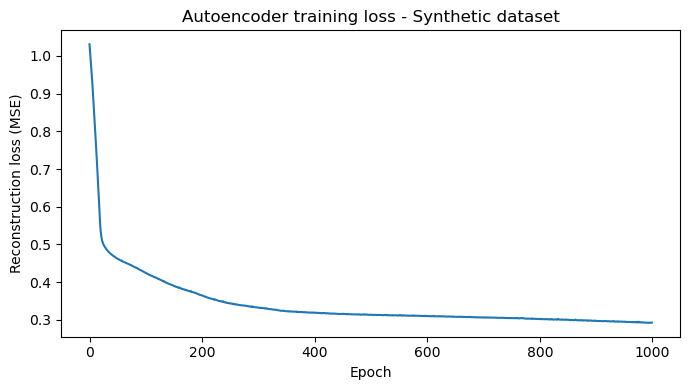

Synthetic dataset
Architecture: 4 -> 8 -> 2 -> 8 -> 4
Epochs: 1000
Batch size: 32
Learning rate: 0.001
Final reconstruction loss: 0.292816


In [48]:
ae_syn_model, ae_syn_projection, ae_syn_losses = train_autoencoder_projection(
    X_syn_scaled_df,
    y_syn,
    dataset_name="Synthetic dataset",
    hidden_dim=8,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3
)

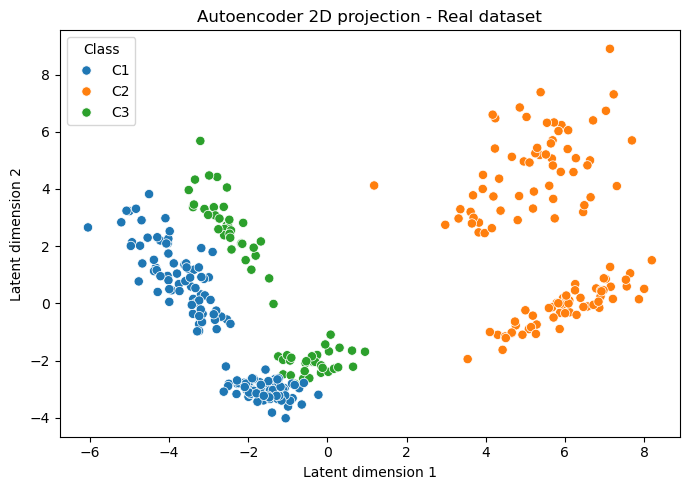

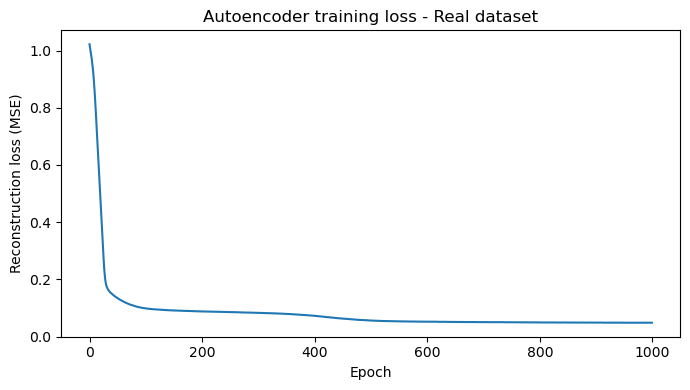

Real dataset
Architecture: 5 -> 10 -> 2 -> 10 -> 5
Epochs: 1000
Batch size: 32
Learning rate: 0.001
Final reconstruction loss: 0.048738


In [49]:
ae_real_model, ae_real_projection, ae_real_losses = train_autoencoder_projection(
    X_real_scaled_df,
    y_real,
    dataset_name="Real dataset",
    hidden_dim=10,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3
)

### SOM

In [54]:
def train_single_som(
    X_scaled,
    map_size=(10, 10),
    learning_rate=0.5,
    sigma=1.5,
    neighborhood_function="gaussian",
    topology="rectangular",
    num_iteration=3000,
    random_seed=42
):
    """
    Trains a SOM with a given set of parameters.
    """

    X = np.asarray(X_scaled, dtype=np.float64)
    input_len = X.shape[1]

    som = MiniSom(
        x=map_size[0],
        y=map_size[1],
        input_len=input_len,
        sigma=sigma,
        learning_rate=learning_rate,
        neighborhood_function=neighborhood_function,
        topology=topology,
        random_seed=random_seed
    )

    som.random_weights_init(X)
    som.train_random(X, num_iteration=num_iteration)

    quantization_error = som.quantization_error(X)

    try:
        topographic_error = som.topographic_error(X)
    except Exception:
        topographic_error = np.nan

    return som, quantization_error, topographic_error

In [55]:
def plot_som_class_map(som, X_scaled, y, title):
    """
    Plots the dominant real class assigned to each SOM neuron.
    The classes are only used for visualization, not for training.
    """

    X = np.asarray(X_scaled, dtype=np.float64)
    y = pd.Series(y).reset_index(drop=True)

    weights = som.get_weights()
    map_x, map_y = weights.shape[0], weights.shape[1]

    labels_per_neuron = [[[] for _ in range(map_y)] for _ in range(map_x)]

    for x_i, label in zip(X, y):
        winner = som.winner(x_i)
        labels_per_neuron[winner[0]][winner[1]].append(label)

    classes = sorted(y.unique(), key=lambda v: str(v))
    class_to_int = {cls: i for i, cls in enumerate(classes)}

    class_grid = np.full((map_x, map_y), np.nan)
    count_grid = np.zeros((map_x, map_y), dtype=int)

    for i in range(map_x):
        for j in range(map_y):
            if len(labels_per_neuron[i][j]) > 0:
                dominant_class = Counter(labels_per_neuron[i][j]).most_common(1)[0][0]
                class_grid[i, j] = class_to_int[dominant_class]
                count_grid[i, j] = len(labels_per_neuron[i][j])

    palette = sns.color_palette("tab10", n_colors=len(classes))
    cmap = ListedColormap(palette.as_hex())
    cmap.set_bad("lightgray")

    plt.figure(figsize=(7, 6))
    plt.imshow(
        class_grid.T,
        origin="lower",
        cmap=cmap,
        vmin=0,
        vmax=len(classes) - 1
    )

    plt.title(title)
    plt.xlabel("SOM x")
    plt.ylabel("SOM y")

    legend_elements = [
        Patch(facecolor=palette[i], label=f"Class {cls}")
        for i, cls in enumerate(classes)
    ]

    plt.legend(
        handles=legend_elements,
        title="Dominant class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [56]:
def plot_som_u_matrix(som, title):
    """
    Plots the U-matrix of the SOM.
    High values indicate stronger separation between neighboring neurons.
    """

    u_matrix = som.distance_map()

    plt.figure(figsize=(7, 6))
    plt.imshow(u_matrix.T, origin="lower")
    plt.colorbar(label="Mean distance to neighboring neurons")
    plt.title(title)
    plt.xlabel("SOM x")
    plt.ylabel("SOM y")
    plt.tight_layout()
    plt.show()

In [57]:
def run_som_experiments(X_scaled, y, dataset_name, configs, feature_names=None):
    """
    Trains several SOMs with different parameters and plots:
    - dominant class heatmap
    - U-matrix

    Then selects the best map according to quantization error.
    """

    X = np.asarray(X_scaled, dtype=np.float64)

    if feature_names is None:
        if isinstance(X_scaled, pd.DataFrame):
            feature_names = list(X_scaled.columns)
        else:
            feature_names = [f"Feature {i+1}" for i in range(X.shape[1])]

    results = []

    for idx, config in enumerate(configs, start=1):

        print(f"\nTraining SOM {idx} - {dataset_name}")
        print(config)

        som, qe, te = train_single_som(
            X_scaled=X,
            map_size=config["map_size"],
            learning_rate=config["learning_rate"],
            sigma=config["sigma"],
            neighborhood_function=config["neighborhood_function"],
            topology=config["topology"],
            num_iteration=config["num_iteration"],
            random_seed=config["random_seed"]
        )

        results.append({
            "config_id": idx,
            "dataset": dataset_name,
            "map_size": config["map_size"],
            "n_neurons": config["map_size"][0] * config["map_size"][1],
            "learning_rate": config["learning_rate"],
            "sigma": config["sigma"],
            "neighborhood_function": config["neighborhood_function"],
            "topology": config["topology"],
            "num_iteration": config["num_iteration"],
            "quantization_error": qe,
            "topographic_error": te,
            "som": som
        })

        plot_som_class_map(
            som,
            X,
            y,
            title=f"SOM dominant class map - {dataset_name} - Config {idx}"
        )

        plot_som_u_matrix(
            som,
            title=f"SOM U-matrix - {dataset_name} - Config {idx}"
        )

        print(f"Quantization error: {qe:.4f}")
        print(f"Topographic error: {te:.4f}")

    results_df = pd.DataFrame(results).drop(columns=["som"])
    display(results_df)

    best_idx = results_df["quantization_error"].idxmin()
    best_config_id = int(results_df.loc[best_idx, "config_id"])
    best_som = results[best_config_id - 1]["som"]

    print(f"\nBest SOM for {dataset_name}: Config {best_config_id}")
    print(results_df.loc[best_idx])

    plot_component_planes(
        best_som,
        feature_names=feature_names,
        title=f"Component planes - Best SOM - {dataset_name}"
    )

    return results, results_df, best_som

In [ ]:
som_configs = [
    {
        "map_size": (10, 10),
        "learning_rate": 0.5,
        "sigma": 1.5,
        "neighborhood_function": "gaussian",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (12, 12),
        "learning_rate": 0.5,
        "sigma": 2.0,
        "neighborhood_function": "gaussian",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (10, 10),
        "learning_rate": 0.3,
        "sigma": 1.5,
        "neighborhood_function": "mexican_hat",
        "topology": "rectangular",
        "num_iteration": 3000,
        "random_seed": 42
    },
    {
        "map_size": (12, 12),
        "learning_rate": 0.3,
        "sigma": 2.0,
        "neighborhood_function": "gaussian",
        "topology": "hexagonal",
        "num_iteration": 3000,
        "random_seed": 42
    }
]

In [ ]:
som_syn_results, som_syn_results_df, best_som_syn = run_som_experiments(
    X_scaled=X_syn_scaled_df,
    y=y_syn,
    dataset_name="Synthetic dataset",
    configs=som_configs
)

In [ ]:
som_real_results, som_real_results_df, best_som_real = run_som_experiments(
    X_scaled=X_real_scaled_df,
    y=y_real,
    dataset_name="Real dataset",
    configs=som_configs
)